# Analyze Logistic Regression Predictions
This notebook analyzes the results of the trained logistic regression model and explores the most impactful features on each class.

These terms may be helpful to understand the features better.  
- Entropy: Measures how irregular / unpredictable a signal is.
- Correlation: Measures how much two axes move together.
- arCoeff: Autoregressive coefficient describes how much the current signal depends on its previous values.
- bandsEnergy: Describes energy in a specific frequency range.
- Gravity acceleration energy: How strong / concentrated the gravity component is over the time window.
- Kurtosis: Measures how peaked or heavy-tailed a signal’s distribution is.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [9]:
MODEL_PATH = "../checkpoints/logistic-regression-2026-04-05-13-37.npz"
features_df = pd.read_csv("../data/features.txt", sep="\s+", header=None, names=["index", "feature_name"], index_col="index")
feature_map = features_df.to_dict()["feature_name"]


In [10]:
data = np.load(MODEL_PATH, allow_pickle=True)
print("Keys in file:", data.files)
CLASS_NAMES = [str(x) for x in data["target_names"].tolist()]
W = data["weight_matrix"]           # shape: (6, 561)
b = data["bias_vector"].reshape(-1) # shape: (6,)
FEATURE_NAMES = [f"{feature_map[i]}" for i in range(1, W.shape[1] + 1)]

print("W shape:", W.shape)
print("b shape:", b.shape)
print("Classes:", CLASS_NAMES)

if "max_iter" in data.files:
    print("max_iter:", int(data["max_iter"]))
if "random_state" in data.files:
    print("random_state:", int(data["random_state"]))
if "learning_rate" in data.files:
    print("learning_rate:", float(data["learning_rate"]))

Keys in file: ['weight_matrix', 'bias_vector', 'max_iter', 'random_state', 'learning_rate', 'target_names']
W shape: (6, 561)
b shape: (6,)
Classes: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']
max_iter: 2491
random_state: 42
learning_rate: 0.06777223076147539



=== WALKING ===

Top positive weights:
tBodyAccJerk-correlation()-X,Y  0.3701
tBodyGyroJerk-correlation()-X,Z  0.3641
tBodyAcc-correlation()-X,Y  0.2889

Top negative weights:
tGravityAcc-entropy()-X -0.3277
fBodyAccMag-energy() -0.2315
fBodyAcc-bandsEnergy()-1,8 -0.1878


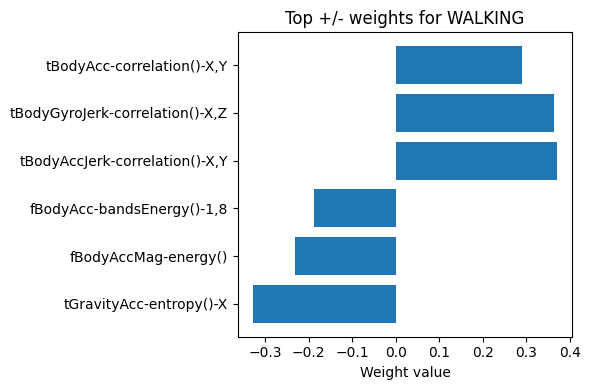


=== WALKING_UPSTAIRS ===

Top positive weights:
tGravityAcc-entropy()-X  0.3172
tGravityAcc-sma()     0.2835
fBodyGyro-kurtosis()-Z  0.2199

Top negative weights:
tBodyGyroJerk-correlation()-X,Z -0.3455
tBodyAccJerk-min()-X -0.2537
tBodyAccJerk-correlation()-X,Z -0.2465

=== WALKING_DOWNSTAIRS ===

Top positive weights:
tBodyAccJerk-max()-X  0.2635
fBodyAccMag-energy()  0.2603
tBodyAcc-arCoeff()-X,4  0.2447

Top negative weights:
tBodyGyro-correlation()-Y,Z -0.3152
tBodyAcc-correlation()-X,Y -0.2791
tBodyAccJerk-correlation()-Y,Z -0.2497

=== SITTING ===

Top positive weights:
tGravityAcc-mean()-Y  0.4965
tBodyGyroJerk-arCoeff()-X,1  0.4779
tGravityAcc-max()-Y   0.4744

Top negative weights:
tBodyGyroJerk-entropy()-X -0.6173
fBodyGyro-entropy()-X -0.4529
tGravityAcc-energy()-Y -0.4459

=== STANDING ===

Top positive weights:
angle(Y,gravityMean)  0.5654
tBodyGyroJerk-entropy()-X  0.5335
fBodyGyro-entropy()-X  0.3429

Top negative weights:
tGravityAcc-min()-Y  -0.6584
tGravityAcc-mean(

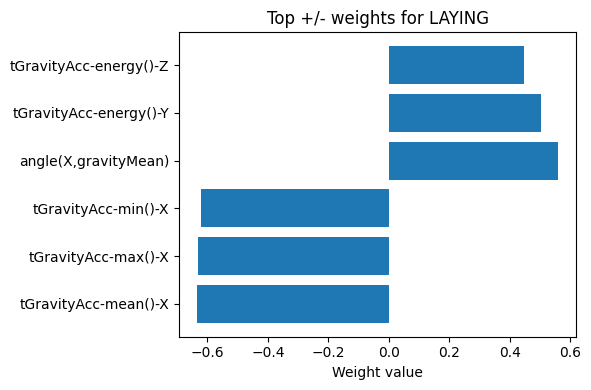

In [11]:
# Examine the top weights for each class
def show_top_weights_for_class(class_idx: int, top_k: int=10) -> None:
    """
    Show the top k positive and negative weights for a given class.
    """
    w = W[class_idx]
    pos_idx = np.argsort(w)[-top_k:][::-1]
    neg_idx = np.argsort(w)[:top_k]

    print(f"\n=== {CLASS_NAMES[class_idx]} ===")

    print("\nTop positive weights:")
    for i in pos_idx:
        print(f"{FEATURE_NAMES[i]:<20} {w[i]: .4f}")

    print("\nTop negative weights:")
    for i in neg_idx:
        print(f"{FEATURE_NAMES[i]:<20} {w[i]: .4f}")


def plot_top_weights_for_class(class_idx: int, top_k: int=10) -> None:
    """
    Plot the top k positive and negative weights for a given class.
    """
    w = W[class_idx]
    pos_idx = np.argsort(w)[-top_k:][::-1]
    neg_idx = np.argsort(w)[:top_k]

    idx = np.concatenate([neg_idx, pos_idx])
    vals = w[idx]
    labels = [FEATURE_NAMES[i] for i in idx]

    plt.figure(figsize=(6, 4))
    plt.barh(range(len(idx)), vals)
    plt.yticks(range(len(idx)), labels)
    plt.xlabel("Weight value")
    plt.title(f"Top +/- weights for {CLASS_NAMES[class_idx]}")
    plt.tight_layout()
    plt.show()


for c in range(len(CLASS_NAMES)):
    show_top_weights_for_class(c, top_k=3)
    if c in [0, 5]:
        plot_top_weights_for_class(c, top_k=3)


=== Top global features ===
tGravityAcc-mean()-Y  0.8757
tGravityAcc-max()-Y   0.8681
tGravityAcc-min()-Y   0.8557
tBodyGyroJerk-entropy()-X  0.8253
tGravityAcc-mean()-X  0.7758
tGravityAcc-min()-X   0.7651
tGravityAcc-max()-X   0.7626
angle(Y,gravityMean)  0.7517
tGravityAcc-energy()-Y  0.6940
angle(X,gravityMean)  0.6939
tGravityAcc-energy()-X  0.6698
tBodyGyroJerk-arCoeff()-X,1  0.6688
tBodyGyroJerk-arCoeff()-X,2  0.6550
tBodyGyro-arCoeff()-X,1  0.5824
tGravityAcc-energy()-Z  0.5774
fBodyGyro-entropy()-X  0.5731
tBodyGyro-entropy()-X  0.5528
tBodyAcc-correlation()-X,Y  0.5238
tBodyGyroJerk-correlation()-X,Z  0.5047
tBodyAccJerk-correlation()-X,Z  0.4690


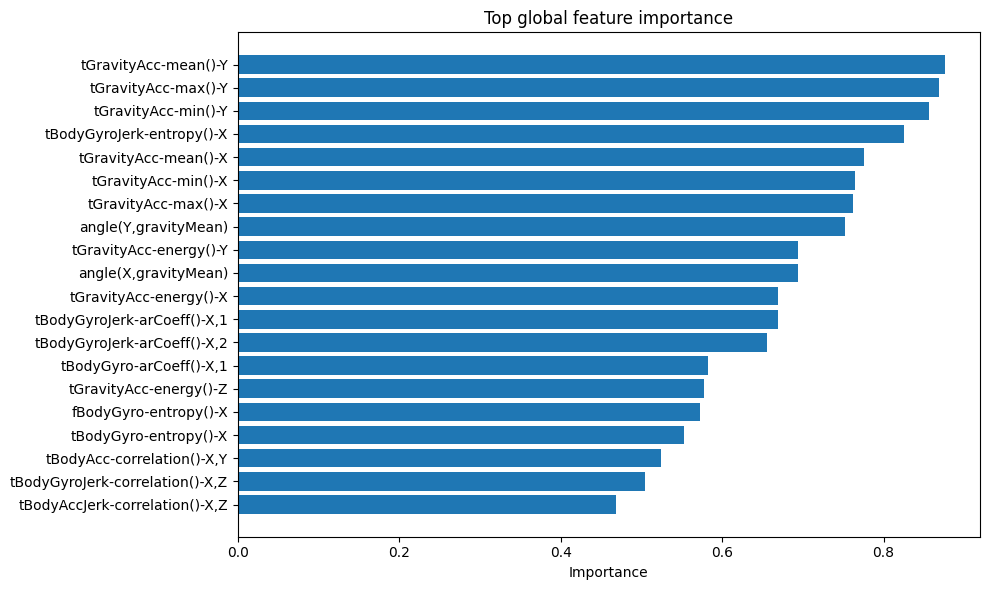

In [12]:
# Global feature importance
importance = np.linalg.norm(W, axis=0)
top_idx = np.argsort(importance)[-20:][::-1]

print("\n=== Top global features ===")
for i in top_idx:
    print(f"{FEATURE_NAMES[i]:<20} {importance[i]: .4f}")

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_idx)), importance[top_idx][::-1])
plt.yticks(range(len(top_idx)), [FEATURE_NAMES[i] for i in top_idx][::-1])
plt.xlabel("Importance")
plt.title("Top global feature importance")
plt.tight_layout()
plt.show()


=== WALKING vs LAYING ===

Most favoring WALKING:
tGravityAcc-mean()-X  0.7037
tGravityAcc-max()-X   0.6900
tGravityAcc-min()-X   0.6733

Most favoring LAYING:
angle(X,gravityMean) -0.6500
tGravityAcc-energy()-Y -0.5722
tGravityAcc-energy()-Z -0.4854


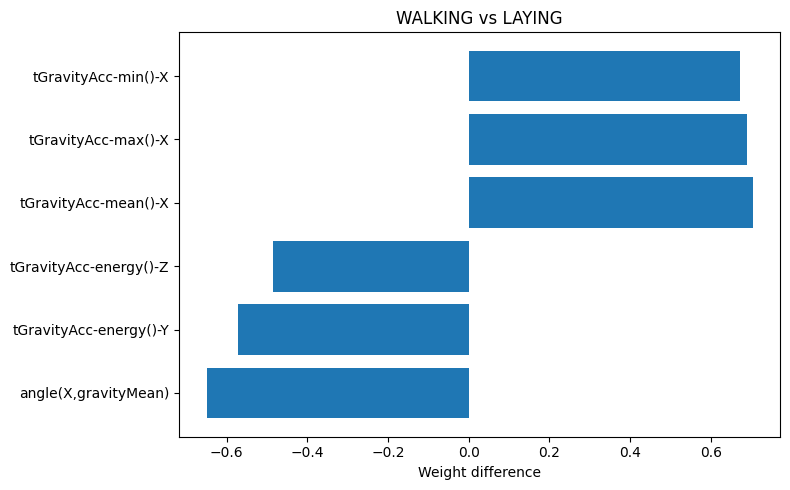


=== SITTING vs STANDING ===

Most favoring SITTING:
tGravityAcc-mean()-Y  1.1539
tGravityAcc-max()-Y   1.1246
tGravityAcc-min()-Y   1.1147

Most favoring STANDING:
tBodyGyroJerk-entropy()-X -1.1508
angle(Y,gravityMean) -0.9283
fBodyGyro-entropy()-X -0.7958


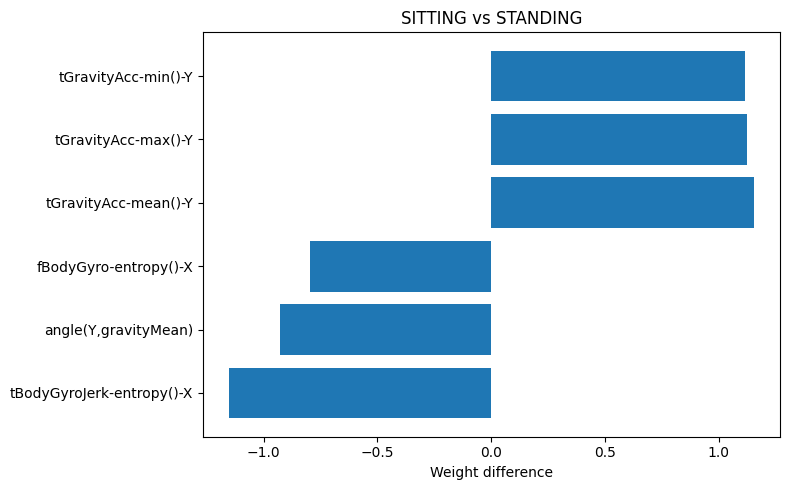


=== WALKING_UPSTAIRS vs WALKING_DOWNSTAIRS ===

Most favoring WALKING_UPSTAIRS:
tBodyGyro-correlation()-Y,Z  0.4833
tGravityAcc-sma()     0.4749
fBodyGyro-kurtosis()-Z  0.4417

Most favoring WALKING_DOWNSTAIRS:
tBodyAccJerk-min()-X -0.4189
tBodyAccJerk-max()-X -0.3896
tBodyGyroJerk-correlation()-X,Y -0.3584


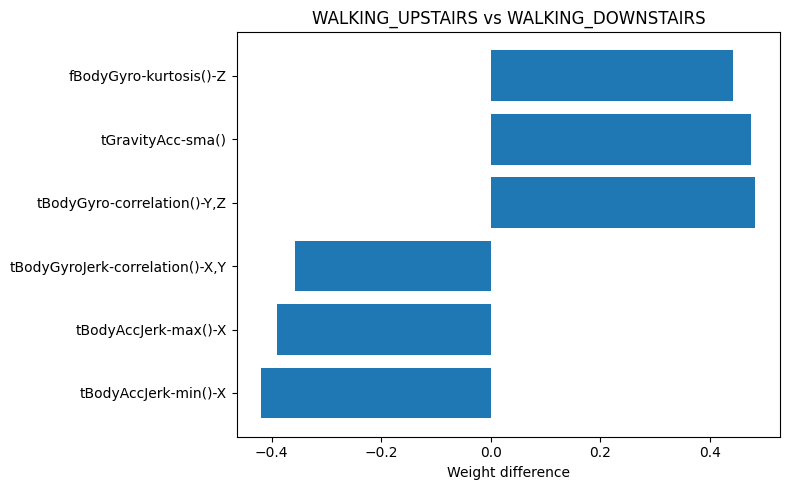

In [13]:
def compare_classes(a_idx: int, b_idx: int, top_k: int=10) -> None:
    """
    Compare two classes by analyzing the difference in their weight vectors.
    Compute the feature-wise difference between the weights
    of class a_idx and class b_idx:

        diff = W[a_idx] - W[b_idx]

    Features with the largest positive differences favor class a_idx,
    while features with the largest negative differences favor class b_idx.
    """
    diff = W[a_idx] - W[b_idx]
    pos_idx = np.argsort(diff)[-top_k:][::-1]
    neg_idx = np.argsort(diff)[:top_k]

    print(f"\n=== {CLASS_NAMES[a_idx]} vs {CLASS_NAMES[b_idx]} ===")

    print(f"\nMost favoring {CLASS_NAMES[a_idx]}:")
    for i in pos_idx:
        print(f"{FEATURE_NAMES[i]:<20} {diff[i]: .4f}")

    print(f"\nMost favoring {CLASS_NAMES[b_idx]}:")
    for i in neg_idx:
        print(f"{FEATURE_NAMES[i]:<20} {diff[i]: .4f}")

    idx = np.concatenate([neg_idx, pos_idx])
    vals = diff[idx]
    labels = [FEATURE_NAMES[i] for i in idx]

    plt.figure(figsize=(8, 5))
    plt.barh(range(len(idx)), vals)
    plt.yticks(range(len(idx)), labels)
    plt.xlabel("Weight difference")
    plt.title(f"{CLASS_NAMES[a_idx]} vs {CLASS_NAMES[b_idx]}")
    plt.tight_layout()
    plt.show()


compare_classes(0, 5, top_k=3)
compare_classes(3, 4, top_k=3)
compare_classes(1, 2, top_k=3)


=== Biases ===
WALKING               0.0535
WALKING_UPSTAIRS     -0.0232
WALKING_DOWNSTAIRS   -0.0306
SITTING               0.0052
STANDING             -0.0115
LAYING                0.0066


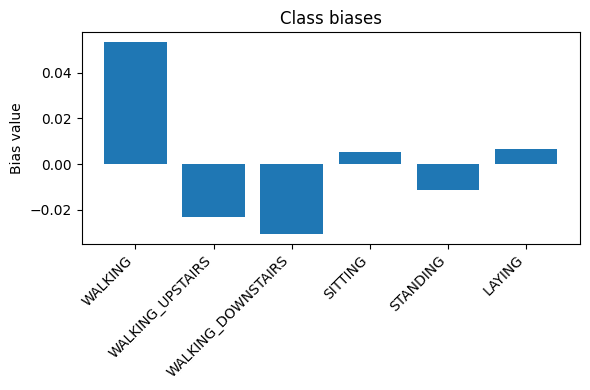

In [14]:
# Compare the biases of classes
print("\n=== Biases ===")
for name, val in zip(CLASS_NAMES, b):
    print(f"{name:<20} {val: .4f}")

plt.figure(figsize=(6, 4))
plt.bar(range(len(CLASS_NAMES)), b)
plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=45, ha="right")
plt.ylabel("Bias value")
plt.title("Class biases")
plt.tight_layout()
plt.show()

They key insights from the above observations are as follows.

- Positive weight → pushes prediction toward that class  
- Negative weight → pushes prediction away from that class  
- Bigger magnitude → stronger influence  

The more influential features can be described as bellow:
- tBodyAcc / tGravityAcc → acceleration (movement vs gravity)
- Gyro → rotation
- Jerk → sudden changes (derivative of motion)
- Entropy / energy / correlation → statistical patterns of motion

High-level feature distinction:

1. Orientation vs Motion  
    Orientation (gravity features) distinguishes:
        Sitting vs standing vs laying  
    Motion patterns distinguish:  
        Walking vs upstairs vs downstairs  

2. Subtle distinctions the model learned  
    Upstairs vs downstairs:  
        Upstairs → gravity + effort  
        Downstairs → impact + irregularity  
    Sitting vs standing:  
        Standing → more entropy (balance adjustments)

What the model uses for each class:
- If motion is smooth, periodic, and coordinated → likely walking  
- If gravity-related variation is high and motion is less smooth → likely upstairs  
- If motion has strong impacts and less coordination → likely downstairs  
- If body orientation is steady and motion randomness is low → likely sitting  
- If upright angle + subtle motion variability → likely standing  
- If gravity aligns with a different axis → laying  


The logistic regression weights show that the model distinguishes activities using both movement patterns and body orientation relative to gravity. Dynamic activities such as walking, walking upstairs, and walking downstairs are mainly identified through acceleration, jerk, and gyroscope features, which capture differences in rhythm, impact, and coordination. For example, walking is associated with more regular and coordinated motion, while upstairs and downstairs movements show stronger gravity and energy-related patterns. In contrast, static activities such as sitting, standing, and laying are primarily separated by gravity and orientation features. Sitting and standing are characterized by stable posture-related signals, while laying is most strongly defined by a different alignment of the body relative to gravity. Overall, the results suggest that the model is learning meaningful physical patterns, with motion features distinguishing active behaviors and gravity-based features distinguishing stationary postures.


